In [3]:
from stochastic_model import StochasticModel
from matplotlib import pyplot as plt

In [4]:
model = StochasticModel("TSLA","heston")
model.fetch_market_data(expiries=model.fetch_expiries()[:5], save_to_class=True, save_to_csv="option_data.csv", atm_threshold=0.10, min_open_interest=2000)

Initialized a heston model for TSLA
Fetching expiries for traded options of TSLA
Fetching market traded options for TSLA for expiry at ('2026-03-02', '2026-03-04', '2026-03-06', '2026-03-09', '2026-03-11')
Fetched data are filtered for min 2000 open interest and max 10.0% moneyness threshold


,strike,lastPrice,impliedVolatility,side,expiry,T
0,410.0,1.34,0.336432,Call,2026-03-02,0.008
1,415.0,0.56,0.341803,Call,2026-03-02,0.008
2,420.0,0.22,0.348639,Call,2026-03-02,0.008
3,430.0,0.03,0.382819,Call,2026-03-02,0.008
4,385.0,0.52,0.449224,Put,2026-03-02,0.008
5,390.0,0.91,0.411871,Put,2026-03-02,0.008
6,392.5,1.22,0.396002,Put,2026-03-02,0.008
7,395.0,1.58,0.381354,Put,2026-03-02,0.008
8,400.0,3.05,0.357672,Put,2026-03-02,0.008
9,410.0,3.59,0.387701,Call,2026-03-04,0.016


In [5]:
r = 0.0372
model.model="black_scholes"
model.quick_calibration(model.data, r, ((0.01,1),), max_calls=100, print_report=True, print_step=10, error_type="mse")
model.batch_price_option(model.data, r=r, params=model.best_params[0], return_column="BS_predictions")

Fetching last underlying price of TSLA
Quick calibration over 100 steps, total 100 calls...
- Step 0:  best params: [0.01]  |  Min error: [0.907]
- Step 10:  best params: [0.11]  |  Min error: [0.86]
- Step 20:  best params: [0.21]  |  Min error: [0.571]
- Step 30:  best params: [0.31]  |  Min error: [0.105]
- Step 40:  best params: [0.32]  |  Min error: [0.102]
- Step 50:  best params: [0.32]  |  Min error: [0.102]
- Step 60:  best params: [0.32]  |  Min error: [0.102]
- Step 70:  best params: [0.32]  |  Min error: [0.102]
- Step 80:  best params: [0.32]  |  Min error: [0.102]
- Step 90:  best params: [0.32]  |  Min error: [0.102]
 Lowest error reached:  [0.10228808]
 Optimal parameters:    [0.32]


In [6]:
model.model  = "heston"
heston_calib = model.calibrate(model.data, r, x0=[0.3,0.13,3,-0.5,0.03], print_report=True, print_step=100,
                bounds = [(0.1, 3), (0.001, 0.7), (0.001, 2), (-1, 1), (0.01, 0.3)], error_type="mse")
model.batch_price_option(model.data, r=r, params=model.best_params, return_column="Heston_predictions")

Fetching last underlying price of TSLA
Calibrating the function...
- Step 0:  best params: [ 0.3   0.13  2.   -0.5   0.03]  |  Min error: 0.701
- Step 100:  best params: [ 0.30329614  0.14827     2.         -0.34657737  0.10955464]  |  Min error: 0.066
- Step 200:  best params: [ 3.          0.7         2.         -0.29930212  0.09613507]  |  Min error: 0.037
 Lowest error reached:  0.03579404440515467
 Optimal parameters:    [ 3.          0.7         2.         -0.36201175  0.09896815]


In [7]:
model.model  = "bates"
bates_calib = model.calibrate(model.data, r, x0=[3,0.3,2,-0.3,0.1,0.05,-0.15,0.3], print_report=True, print_step=100,
                bounds = [(0.1, 4), (0.001, 0.7), (0.001, 3), (-1, 1), (0.01, 0.3),
                          (0.001, 2), (-0.3,0.3), (0.01,1)], error_type="mse")
model.batch_price_option(model.data, r=r, params=model.best_params, return_column="Bates_predictions")

Fetching last underlying price of TSLA
Calibrating the function...
- Step 0:  best params: [ 3.    0.3   2.   -0.3   0.1   0.05 -0.15  0.3 ]  |  Min error: 0.056
- Step 100:  best params: [ 3.01095755  0.47259222  2.02917522 -0.42356983  0.10596269  0.01359017
 -0.25424864  0.22517462]  |  Min error: 0.047
- Step 200:  best params: [ 3.01555371  0.7         2.02603788 -0.28223063  0.08884582  0.1426325
 -0.3         0.27444529]  |  Min error: 0.027
- Step 300:  best params: [ 3.1281474   0.7         2.17029009  0.08383639  0.06574672  0.82454412
 -0.27488805  0.14566559]  |  Min error: 0.007
- Step 400:  best params: [ 3.36208956  0.7         2.22715322  0.03180251  0.06726853  1.02323209
 -0.21351274  0.01      ]  |  Min error: 0.006
- Step 500:  best params: [ 3.79394394  0.7         2.32035336  0.04025751  0.06383962  1.47411561
 -0.16211049  0.09259567]  |  Min error: 0.005


C:\Users\Shahram\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\stochastic_model.py:146: IntegrationWarning: The maximum number of subdivisions (250) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integration_value = quad(lambda u: self.Lewis_cf_integration(u, self.Bates_char_func,


- Step 600:  best params: [ 4.          0.7         2.35121829  0.01399636  0.06389394  1.65366273
 -0.14696361  0.08425362]  |  Min error: 0.005
- Step 700:  best params: [ 4.          0.7         2.18709827  0.02152573  0.0660088   0.94883071
 -0.22098557  0.07478204]  |  Min error: 0.004
- Step 800:  best params: [ 4.          0.7         2.09559539  0.03938079  0.06595858  0.67772297
 -0.29999999  0.07131153]  |  Min error: 0.004
- Step 900:  best params: [ 4.          0.7         2.02129567  0.05633364  0.06565664  0.6839718
 -0.3         0.06809073]  |  Min error: 0.004
 Lowest error reached:  0.004117254798529824
 Optimal parameters:    [ 4.          0.7         2.02460768  0.05441379  0.06570358  0.68311051
 -0.3         0.06817244]


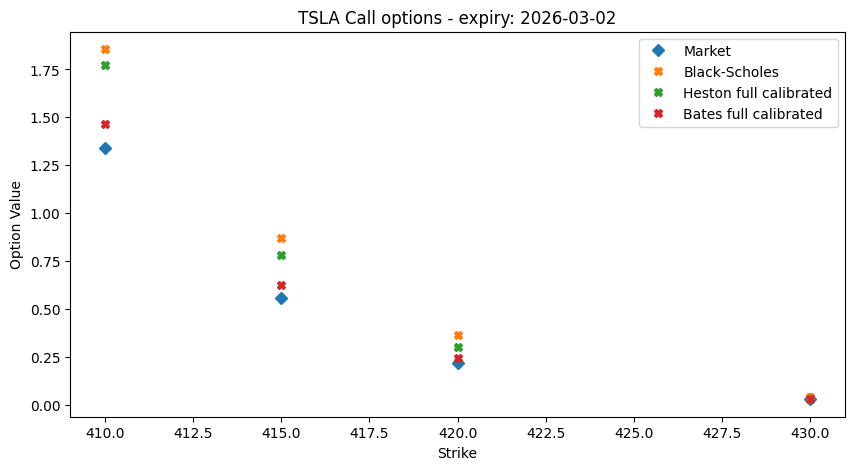

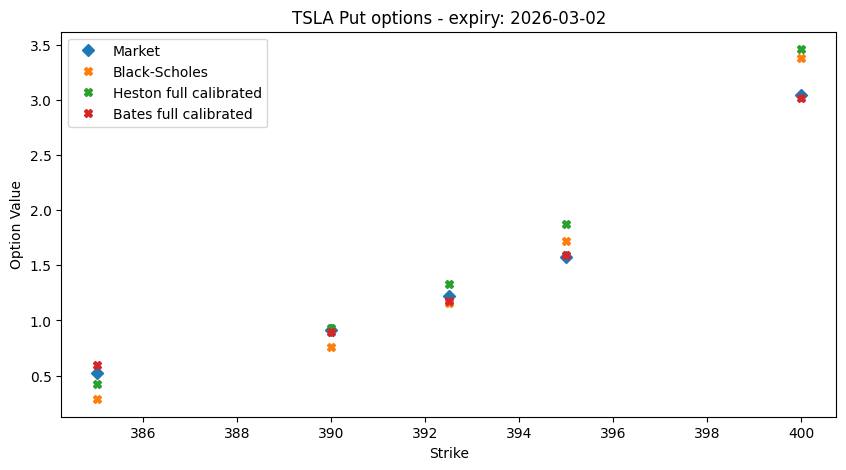

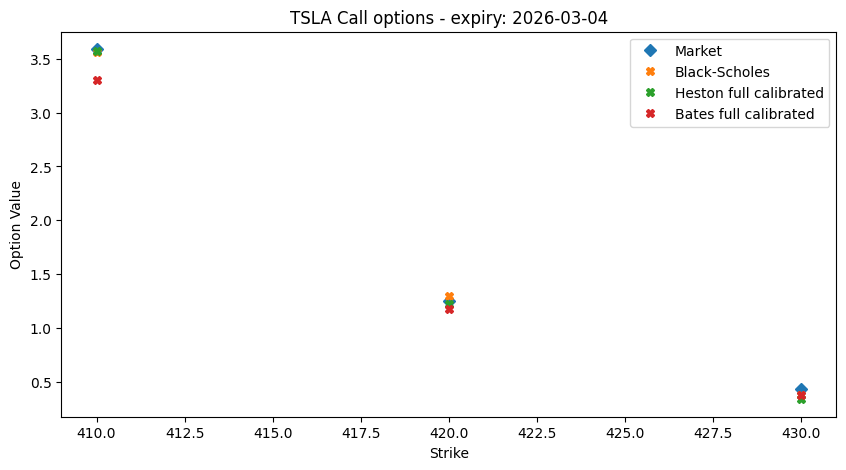

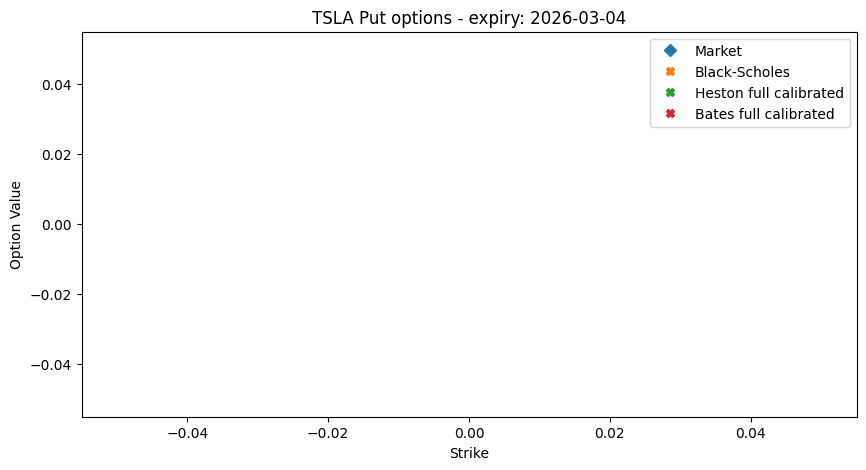

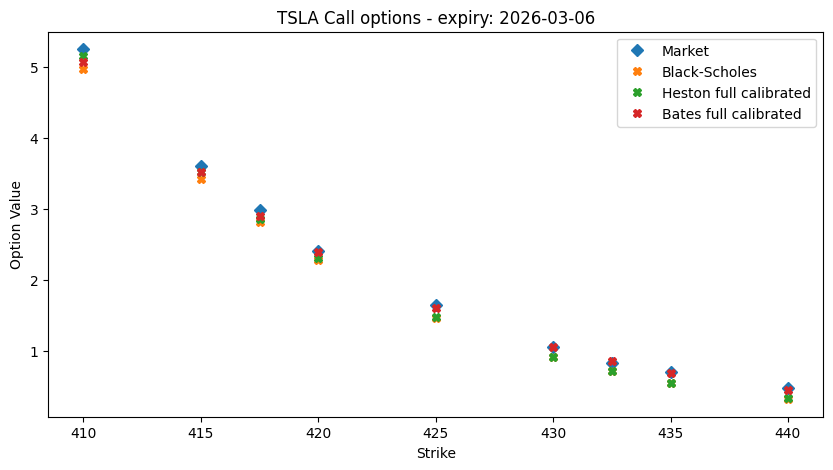

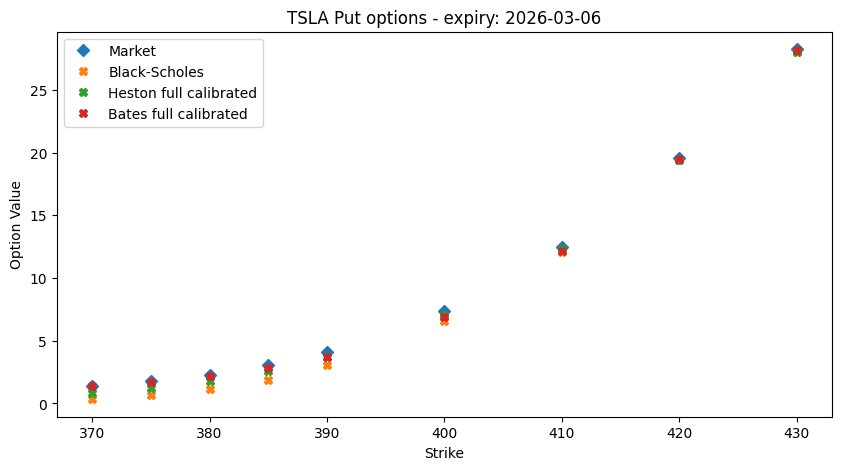

In [8]:
def plot_data(data, columns, labels, title):
    plt.figure(figsize=(10,5))
    for i in range(len(labels)):
        plt.plot(data["strike"], data[columns[i]], "D" if i==0 else "X", label=labels[i])
        plt.legend()
        plt.ylabel("Option Value")
        plt.xlabel("Strike")
        plt.title(title)

for expiry in model.data["expiry"].unique():
    for side in ["Call", "Put"]:
        options_df = model.data.query("expiry == @expiry and side == @side")
        plot_data(options_df,
                  columns=["lastPrice", "BS_predictions", "Heston_predictions", "Bates_predictions"],
                  labels=["Market", "Black-Scholes", "Heston full calibrated", "Bates full calibrated"],
                  title=f"{model.ticker} {side} options - expiry: {expiry}")